# AirBnB NYC Analytics Project 

* Project by Nhi Bui · Villanova University · [GitHub](https://github.com/nhibui23/airbnb-saas-product-analytics) · [LinkedIn](https://linkedin.com/in/nhiuyenbui)

## 05. Location Analysis: Where Should Airbnb Grow?

> "If Airbnb had to pick one neighborhood to invest host acquisition dollars in, where should it go?"

This notebook compares boroughs across listing volume, review quality, and engagement, then drills into the borough with the clearest growth signal to identify specific target neighborhoods.

**Key findings**
- Which borough has the best ratio of review quality to listing supply
- The top neighborhoods within that borough for new host acquisition
- The competitive landscape a new host would enter

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

df = pd.read_csv('../data/Airbnb_Open_Data_Cleaned.csv')
print(df.shape)

# Apply Airbnb branding guidelines
airbnb_coral = '#FF5A5F'  
airbnb_teal = '#00A699'   
airbnb_orange = '#FC642D' 
airbnb_dark = '#484848'   
airbnb_gray = '#767676'  

airbnb_palette = [airbnb_coral, airbnb_teal, airbnb_orange, airbnb_dark, airbnb_gray]

sns.set_palette(airbnb_palette)
sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'

(63718, 21)


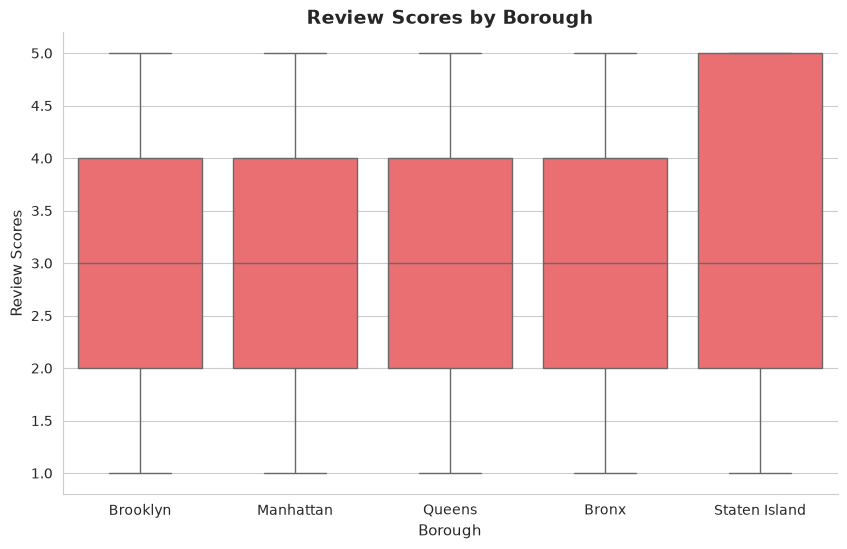

In [7]:
#Compare review ratings for different boroughs
plt.figure(figsize=(10, 6))
sns.boxplot(x='neighbourhood group', y='review rate number', data=df)
plt.title('Review Scores by Borough')
plt.xlabel('Borough')
plt.ylabel('Review Scores')
plt.show()


### Key Takeaway

**Review Scores by Borough (Boxplot):**

* All boroughs show similar median review ratings (~3.0), with Staten Island displaying the widest variance - indicating inconsistent listing quality
* Brooklyn, Manhattan, Queens, and Bronx show identical distributions, suggesting that borough alone doesn'tstrongly differentiate review quality.

### Interpretation

* Median ratings are consistent across NYC, as the "average guest experience" is roughly the same whether you're in Manhattan or the Bronx
- Staten Island's wider variance likely reflects its smaller listing pool with fewer listings, so some outliers move the spread more than they would in a larger borough

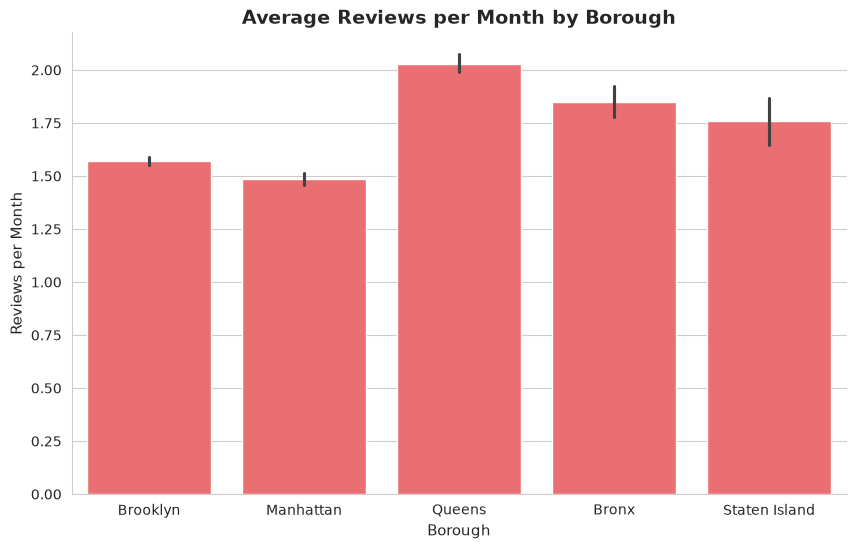

In [3]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='neighbourhood group', y='reviews per month')
plt.title('Average Reviews per Month by Borough')
plt.xlabel('Borough')
plt.ylabel('Reviews per Month')
plt.show()

### Key Takeaway

**Average Reviews per Month by Borough (Barplot):**
* **Queens leads in monthly review activity** (~2.0 reviews/month)
* Bronx (~1.85) and Staten Island (~1.75) follow closely
* **Manhattan ranks lowest** (~1.49) despite having the most listings, which is a surprising inversion

## Interpretation

* Outer boroughs appear to have **stronger per-listing engagement** 
* The likely driver is **less competition**: in Manhattan, listings compete against ~25,000 others on the same search page, so even good listings get fewer engagement
* In Queens and the Bronx, the smaller listing pool means **higher visibility per listing**, which translates into more bookings and more reviews

In [4]:
#Summary table combining average review ratings, average reviews per month, and listing counts by borough
df.groupby('neighbourhood group').agg(
    avg_rating=('review rate number', 'mean'),
    avg_reviews_per_month=('reviews per month', 'mean'),
    listing_count=('id', 'count')
).sort_values('avg_reviews_per_month', ascending=False)

,avg_rating,avg_reviews_per_month,listing_count
neighbourhood group,,,
Queens,3.339369,2.028555,9388
Bronx,3.355295,1.848795,2049
Staten Island,3.392622,1.759236,759
Brooklyn,3.269292,1.569812,25775
Manhattan,3.285859,1.486506,25747


### Key Takeaway

**Growth Opportunity Analysis:** To find where Airbnb should focus growth, we look for boroughs combining high quality (ratings), high engagement (reviews per month), and low supply (room to grow).

* **Staten Island**: highest rating (3.39), lowest supply (755), but small sample makes it unreliable
* **Manhattan**: most listings (25,747), lowest activity, below-average ratings, which signals a saturated market
* **Queens**: leads in activity but already has moderate supply (9,388 listings)
* **Bronx**: strongest growth candidate with highest rating (3.36), second-highest activity (1.85/month), only 2,049 listings

### Interpretation

* The Bronx issweet spot of **high quality & meaningful demand & low supply** 
* Staten Island's higher rating is tempting but uncertain with only 755 listings, the average could change with a handful of new reviews
* Manhattan's saturation is showing in the numbers: lots of listings, but each one captures less guest activity
* Queens looks potential but moderate-supply markets are harder to disrupt than under-supplied ones 

### Recommendation

1. Airbnb should focus deeper analysis on the Bronx to identify high-potential neighborhoods for targeted host acquisition. The combination of strong ratings, demand, and minimal supply is the profile Airbnb should be looking for when prioritizing new market investment.

2. We should target specific Bronx neighborhoods (Mott Haven, Schuylerville, Belmont) to design specific product features around those markets.

In [5]:
#Drill down to the top neighbourhoods within the Bronx
bronx = df[df['neighbourhood group'] == 'Bronx']
bronx.groupby('neighbourhood').agg(
    avg_rating=('review rate number', 'mean'),
    avg_reviews_per_month=('reviews per month', 'mean'),
    listing_count=('id', 'count')
).sort_values('avg_reviews_per_month', ascending=False).head(10)

,avg_rating,avg_reviews_per_month,listing_count
neighbourhood,,,
Castle Hill,2.750000,3.318750,8
Schuylerville,3.488889,2.597556,45
East Morrisania,3.277778,2.518333,18
Van Nest,3.363636,2.489091,22
Mott Haven,3.434426,2.447541,122
Throgs Neck,3.442308,2.441923,52
Belmont,3.548387,2.401613,31
Woodlawn,3.208333,2.399167,24
Mount Eden,4.200000,2.343000,10


## Location Analysis Conclusion  

**Top Growth Neighbourhoods in the Bronx:**
1. **Mott Haven** with 122 listings, 3.43 avg rating, 2.45 reviews/month as it has the most reliable data and strong performance 
2. **Schuylerville** with 45 listings, 3.49 avg rating, 2.60 reviews/month, as it has the highest activity and a strong average rating
3. **Belmont** with 31 listings, 3.55 avg rating, 2.40 reviews/month, as it has the highest average rating and a strong number of reviews/month

**Product Feature Recommendations:**
1. **Targeted host acquisition campaigns** 
Mott Haven, Schuylerville, and Belmont demonstrate guest demand (high reviews/month) with limited supply (below 125 listings/area)

=> Hosts who list here are likely to succeed

2. **New host incentives** 
Airbnb should implement reduced service fees or professional photography for first-time hosts in these areas to accelerate supply growth

3. **Neighbourhood spotlight features** 
In the Airbnb app, it is suggested to drive guest awareness of these emerging areas, positioning them as authentic NYC alternatives to saturated Manhattan listings in spotlight features of apps

4. **Performance monitoring dashboard** 
Airbnb can install dashboard to track whether increased host supply maintains or dilutes the current quality and engagement levels in these neighbourhoods for real-time adjustments